In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## Read distance info and save as arrays

In [2]:
dist_data = pd.read_csv('../data/selected_structures_1000_nm_thr.tsv', sep='\t')
transc_data = pd.read_csv('../data/transcriptional_data_1000_nm_thr.tsv', sep='\t')

dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='Chromosome copy number')

n_loci = 38

### Iterate through all structures and save them as an image

In [66]:
for id, row in dataset.iterrows():
    
    struct_id = int(row['Chromosome copy number'])
    state = int(row['BACH1'])
    if state == 0:
        state_save = 'inactive'
    else:
        state_save = 'active'
    
    dists = row.iloc[1 : -1]
    
    locus_i = 0
    dist_i = np.zeros((n_loci, n_loci))
    
    for i in range(0, n_loci):
        for j in range(i + 1, n_loci):
            dist_i[i,j] = dists.iloc[locus_i]
            
            locus_i += 1
    
    dist_i = dist_i + dist_i.T
    
    
    dist_i = pd.DataFrame(dist_i)
    dist_i.to_csv(f"../data/distance_maps/{state_save}/structure_{struct_id}.tsv", sep='\t', header = False, index=False)

In [60]:
norm = (dist_i - 0) / (1000 - 0)  # scale to [0,1]
img = (norm * 255).astype(np.uint8)
    
Image.fromarray(img).save(f"trial_image.png")

## Create data splits and normalize separately before saving to images for model training

In [ ]:
# WILL NEED TO RUN TRAIN/TEST SPLITS FIRST, AND ONCE DONE, NORMALIZE AND SAVE IMAGES ACCORDINGLY SEPARATELY

In [1]:
import functions.cnn_helpers as help_funcs

In [ ]:
image = help_funcs.kfold_splits(src_folder = '../data/distance_maps/', dst_folder = '../data/CNN_splits')

Creating fold 1/5...
Train size: 1912, Validation size: 638, Test size: 638
../data/distance_maps/active/structure_6953.tsv
../data/CNN_splits_raw/fold_0/train/active/structure_6953.png
../data/distance_maps/inactive/structure_11360.tsv
../data/CNN_splits_raw/fold_0/train/inactive/structure_11360.png
../data/distance_maps/inactive/structure_10851.tsv
../data/CNN_splits_raw/fold_0/train/inactive/structure_10851.png
../data/distance_maps/active/structure_10470.tsv
../data/CNN_splits_raw/fold_0/train/active/structure_10470.png
../data/distance_maps/inactive/structure_69.tsv
../data/CNN_splits_raw/fold_0/train/inactive/structure_69.png
../data/distance_maps/active/structure_8074.tsv
../data/CNN_splits_raw/fold_0/train/active/structure_8074.png
../data/distance_maps/active/structure_10986.tsv
../data/CNN_splits_raw/fold_0/train/active/structure_10986.png
../data/distance_maps/active/structure_354.tsv
../data/CNN_splits_raw/fold_0/train/active/structure_354.png
../data/distance_maps/inactive

In [5]:
image.shape

(38, 38)

In [6]:
import seaborn as sns

<Axes: >

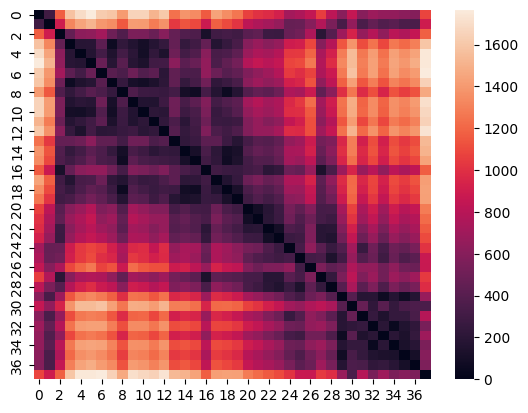

In [7]:
sns.heatmap(image)